# BHARATH BUILDS — 21 DAYS TO ML ENGINEER

## DAY 6 — K-NEAREST NEIGHBORS (KNN)

---

## OBJECTIVE

Understand K-Nearest Neighbors (KNN) as an instance-based learning algorithm and learn how distance, K value, feature scaling, and validation affect model performance.

---

## TODAY'S TOPICS

### 1. KNN Intuition
- What is KNN?
- How KNN makes predictions
- Instance-based learning
- Lazy learning

### 2. Distance Metrics
- Why distance matters
- Euclidean Distance
- Manhattan Distance
- How KNN finds nearest points

### 3. Choosing K
- What is K?
- Small K vs Large K
- Effect of K on predictions
- How to select a suitable K

### 4. Bias vs Variance
- Small K → Low Bias, High Variance
- Large K → High Bias, Low Variance
- Overfitting vs Underfitting
- Effect of K on decision boundaries

### 5. Feature Scaling
- Why scaling matters in KNN
- Effect of different feature ranges
- Standardization
- StandardScaler

### 6. KNN Pipeline
- Train / Test Split
- Feature Scaling
- KNN Model
- Prediction
- Evaluation

### 7. K-Value Experiment
- Try multiple K values
- Compare validation performance
- K vs Accuracy
- Identify the best K

### 8. Cross-Validation
- Why one validation split may not be enough
- Cross-validation for K selection
- Mean validation performance
- Selecting the best K

### 9. Decision Boundary
- How K affects the decision boundary
- Small K → Complex boundary
- Large K → Smooth boundary

### 10. Advantages and Limitations
- Advantages of KNN
- Limitations of KNN
- Computational cost
- Sensitivity to scaling
- High-dimensional data

---

## PRACTICAL OBJECTIVE

Build a KNN classification experiment and understand how different K values affect model performance.

---

## PRACTICAL WORKFLOW

Dataset
↓
Train / Test Split
↓
Feature Scaling
↓
KNN
↓
Try Multiple K Values
↓
Validation Performance
↓
Cross-Validation
↓
Select Best K
↓
Final Model
↓
Evaluation

---

## DELIVERABLE

### KNN Experiment

- KNN classification model
- Feature scaling using Pipeline
- Multiple K-value comparison
- Validation performance comparison
- Cross-validation
- Best K selection
- Final model evaluation
- Decision boundary visualization

---

## KEY ENGINEERING IDEA

> KNN predicts a new data point based on the classes of its nearest training examples.

```text
New Data Point
      ↓
Calculate Distance
      ↓
Find K Nearest Neighbors
      ↓
Majority Voting
      ↓
Final Prediction

step 1 : import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

step2: load the dataset

In [2]:
data=load_wine()
X=data.data
y=data.target

print("featues shape:",X.shape)
print("target shape:",y.shape)

print("clases:",data.target_names)

featues shape: (178, 13)
target shape: (178,)
clases: ['class_0' 'class_1' 'class_2']


step 3: train test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 142
Testing samples: 36


step 4: KNN without scaling

In [4]:
knn=KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)

print("accuracy without scaling:",accuracy_score(y_test,y_pred))


accuracy without scaling: 0.8055555555555556


step 5: KNN with feature scaling

In [5]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)

X_test_scaled=scaler.transform(X_test)
print(" scaling completed")

 scaling completed


In [6]:
knn_scaled=KNeighborsClassifier(n_neighbors=5)

knn_scaled.fit(X_train_scaled,y_train)
y_pred_scaled=knn_scaled.predict(X_test_scaled)

print("accuracy with scaling:",accuracy_score(y_test,y_pred_scaled))
#

accuracy with scaling: 0.9722222222222222


step 7: build a KNN pipeline

In [7]:
knn_pipeline=Pipeline([
    ("scaler",StandardScaler()),
    ("knn",KNeighborsClassifier(n_neighbors=5))

])

knn_pipeline.fit(X_train,y_train)
y_pred_pipeline=knn_pipeline.predict(X_test)

print("accuracy with pipeline:",accuracy_score(y_test,y_pred_pipeline))


accuracy with pipeline: 0.9722222222222222


step 8 : experiment with multiple k values

In [11]:
k_values = [1, 3, 5, 7, 9, 11, 15]

results = []

for k in k_values:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    model.fit(X_train, y_train)

    score = model.score(X_test, y_test)

    results.append({
        "K": k,
        "Accuracy": score
    })

results_df = pd.DataFrame(results)

results_df

,K,Accuracy
0,1,0.972222
1,3,0.972222
2,5,0.972222
3,7,1.000000
4,9,1.000000
5,11,1.000000
6,15,1.000000


step 9: visualise K vs accuracy

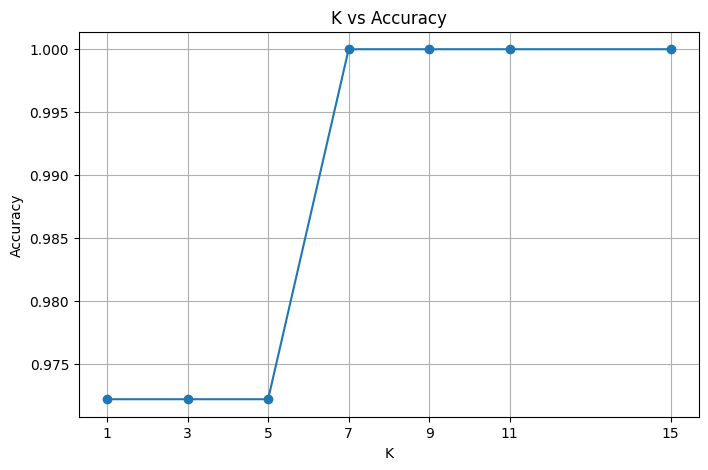

In [13]:
plt.figure(figsize=(8,5))
plt.plot(results_df["K"],results_df["Accuracy"],marker="o")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.xticks(results_df["K"])
plt.grid(True)
plt.show()

step 10: cross validation for k selection

In [14]:
cv_result=[]

for k in k_values:
    model=Pipeline([
        ("scaler",StandardScaler()),
        ("knn",KNeighborsClassifier(n_neighbors=k))
    ])

    scores=cross_val_score(model,X,y,cv=5,scoring="accuracy")

    cv_result.append({
        "K":k,
        "mean_accuracy":scores.mean(),
        "std_accuracy":scores.std()
    })
cv_result_df=pd.DataFrame(cv_result)
cv_result_df
#


,K,mean_accuracy,std_accuracy
0,1,0.949524,0.032894
1,3,0.943968,0.039630
2,5,0.949365,0.037911
3,7,0.966508,0.020747
4,9,0.966349,0.010958
5,11,0.955238,0.022389
6,15,0.955238,0.028459


step 11: select best k value from above exp

In [15]:
best_row=cv_result_df.loc[cv_result_df["mean_accuracy"].idxmax()]
best_k=int(best_row["K"])
best_mean_accuracy=best_row["mean_accuracy"]
best_std_accuracy=best_row["std_accuracy"]

print("best k:",best_k)
print("best mean accuracy:",best_mean_accuracy)
print("best std accuracy:",best_std_accuracy)


best k: 7
best mean accuracy: 0.9665079365079364
best std accuracy: 0.020746948644437477


step12: final knn model

In [18]:
final_model=Pipeline([
    ("scaler",StandardScaler()),
    ("knn",KNeighborsClassifier(n_neighbors=best_k))
])

final_model.fit(X_train,y_train)

y_pred=final_model.predict(X_test)

accuracy=accuracy_score(y_test,y_pred)

print("Best k:",best_k)
print(" Final best k Accuracy:",accuracy)

Best k: 7
 Final best k Accuracy: 1.0


step 13 : confusion matrix

In [19]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


step 14: classification import

In [21]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



step 15: decesipon boundary visualization

In [25]:
from sklearn.datasets import make_moons

X_vis,y_vis=make_moons(n_samples=300,noise=0.25,random_state=42)

X_vis_scaled=StandardScaler().fit_transform(X_vis)

knn_vis=KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_vis_scaled,y_vis)



KNeighborsClassifier()

step 16: comparision of diffrent k values in visually

In [29]:
for k in [1,5,15]:
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(X_vis_scaled,y_vis)
    y_vis_pred=model.predict(X_vis_scaled)


    print("k=",k)
    print(confusion_matrix(y_vis,y_vis_pred))
    print(classification_report(y_vis,y_vis_pred))

k= 1
[[150   0]
 [  0 150]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       150
           1       1.00      1.00      1.00       150

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

k= 5
[[141   9]
 [  6 144]]
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       150
           1       0.94      0.96      0.95       150

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300

k= 15
[[140  10]
 [ 11 139]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       150
           1       0.93      0.93      0.93       150

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93

## KNN EXPERIMENT — DETAILED INTERPRETATION

### 1. Decision Boundary: K = 1

- K = 1 considers only the single nearest neighbor.
- The model achieved **100% accuracy** on the 300-point visualization dataset.
- All 300 points were classified correctly.
- The confusion matrix contains zero misclassifications.
- The model is highly dependent on individual nearby points.
- Even a noisy or incorrectly labelled point can influence the prediction.
- This creates a very flexible and complex decision boundary.
- Therefore, K = 1 can have **low bias and high variance**.
- High variance means the model can be sensitive to small changes in the data.
- So, 100% accuracy does not automatically mean that K = 1 is the best generalizing model.

### K = 1 Summary

**K = 1 → Very Local → Complex Boundary → High Variance → Overfitting Risk**

---

## 2. Decision Boundary: K = 5

- K = 5 considers the five nearest neighbors.
- The model achieved approximately **95% accuracy**.
- 285 out of 300 points were classified correctly.
- 15 points were misclassified.
- The prediction is no longer dependent on only one neighboring point.
- Majority voting makes the prediction more stable.
- The decision boundary becomes smoother compared with K = 1.
- K = 5 provides a more balanced neighborhood for prediction.

### K = 5 Summary

**K = 5 → More Neighbors → Majority Voting → More Stable Boundary**

---

## 3. Decision Boundary: K = 15

- K = 15 considers 15 nearest neighbors.
- The model achieved approximately **93% accuracy**.
- 279 out of 300 points were classified correctly.
- 21 points were misclassified.
- A larger neighborhood makes the model less sensitive to individual points.
- The decision boundary becomes smoother.
- However, local patterns may be ignored.
- This can increase bias and create an underfitting risk.

### K = 15 Summary

**K = 15 → Larger Neighborhood → Smoother Boundary → Higher Bias**

---

## 4. Comparing K Values

| K | Accuracy | Main Behaviour |
|---:|---:|---|
| 1 | 100% | Very complex and highly local |
| 5 | 95% | More balanced |
| 15 | 93% | Smoother and less local |

### Observation

- Increasing K does not always increase accuracy.
- K = 1 gave the highest accuracy on this particular visualization dataset.
- K = 5 reduced the sensitivity to individual points.
- K = 15 produced a smoother boundary but lower accuracy.
- Therefore, K must be treated as a hyperparameter that needs experimentation.

---

## 5. Cross-Validation Results

| K | Mean Accuracy | Std Accuracy |
|---:|---:|---:|
| 1 | 94.95% | 3.29% |
| 3 | 94.40% | 3.96% |
| 5 | 94.94% | 3.79% |
| 7 | **96.65%** | 2.07% |
| 9 | **96.63%** | 1.10% |
| 11 | 95.52% | 2.24% |
| 15 | 95.52% | 2.85% |

### Interpretation

- Cross-validation gives a different perspective from the single visualization experiment.
- K = 7 achieved the highest mean accuracy.
- K = 7 achieved approximately **96.65% mean accuracy**.
- K = 9 achieved approximately **96.63% mean accuracy**.
- K = 7 and K = 9 are therefore the strongest K values in this experiment.
- K = 3 produced the lowest mean accuracy among the tested values.
- K = 1 did not have the highest cross-validation accuracy despite achieving 100% on the visualization dataset.
- This shows why we should not select K based on one result alone.

---

## 6. Understanding Mean Accuracy

- Mean accuracy represents the average accuracy across the cross-validation folds.
- A higher mean accuracy generally indicates stronger validation performance.
- K = 7 has the highest mean accuracy in this experiment.
- Therefore, K = 7 is the strongest performer based on mean cross-validation accuracy.
- The difference between K = 7 and K = 9 is very small.
- K = 7 → approximately **96.65%**
- K = 9 → approximately **96.63%**

### Key Point

**Higher mean validation performance → Stronger candidate for K selection**

---

## 7. Understanding Standard Deviation

- Standard deviation shows how much the accuracy changes between cross-validation folds.
- Lower standard deviation indicates more consistent performance.
- K = 9 has the lowest standard deviation among the tested K values.
- K = 9 → approximately **1.10% standard deviation**.
- K = 7 → approximately **2.07% standard deviation**.
- Therefore, K = 9 has slightly more consistent validation performance.
- The difference in mean accuracy between K = 7 and K = 9 is extremely small.

### Key Point

**Mean Accuracy → Performance**

**Standard Deviation → Consistency**

---

## 8. Why K = 7 Is Selected

- K = 7 produced the highest mean cross-validation accuracy.
- Mean accuracy is approximately **96.65%**.
- K = 9 is extremely close at approximately **96.63%**.
- Since the objective of this experiment is to identify the highest validation performer, K = 7 becomes the selected K.
- However, K = 9 is also a strong candidate because its standard deviation is lower.
- This demonstrates that model selection can involve both performance and stability.

### Selected K

**K = 7**

**Mean Cross-Validation Accuracy ≈ 96.65%**

---

## 9. Small K vs Large K

### Small K

- Uses fewer neighbors.
- Focuses strongly on local observations.
- Produces more flexible decision boundaries.
- More sensitive to noise.
- Lower bias.
- Higher variance.
- Greater overfitting risk.

### Large K

- Uses more neighbors.
- Considers a larger region of the dataset.
- Produces smoother decision boundaries.
- Less sensitive to individual observations.
- Higher bias.
- Lower variance.
- Greater underfitting risk.

---

## 10. Effect of K on Decision Boundary

```text
K = 1
↓
Very Local Decisions
↓
Complex Boundary
↓
High Variance